In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
df = yf.download('005380.KS','2010-01-01','2025-06-01')
df.to_excel("현대차.xlsx")
df.to_csv("현대차.csv")
df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,005380.KS,005380.KS,005380.KS,005380.KS,005380.KS
Date,,,,,
2010-01-04,79891.101562,80898.132254,79219.747768,80226.778460,1602697
2010-01-05,73848.921875,79891.106392,73848.921875,79219.752557,3045198
2010-01-06,74520.281250,75527.312078,72506.219595,74520.281250,1681152
2010-01-07,71163.507812,74855.953973,70492.153965,74520.277049,1736811
2010-01-08,71163.507812,71834.861660,68813.769347,71163.507812,2175189


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3793 entries, 2010-01-04 to 2025-05-30
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 005380.KS)   3793 non-null   float64
 1   (High, 005380.KS)    3793 non-null   float64
 2   (Low, 005380.KS)     3793 non-null   float64
 3   (Open, 005380.KS)    3793 non-null   float64
 4   (Volume, 005380.KS)  3793 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 177.8 KB


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

[*********************100%***********************]  1 of 1 completed


Price              Close          High           Low          Open    Volume
Ticker         005380.KS     005380.KS     005380.KS     005380.KS 005380.KS
Date                                                                        
2010-01-04  79891.101562  80898.132254  79219.747768  80226.778460   1602697
2010-01-05  73848.921875  79891.106392  73848.921875  79219.752557   3045198
2010-01-06  74520.281250  75527.312078  72506.219595  74520.281250   1681152
2010-01-07  71163.507812  74855.953973  70492.153965  74520.277049   1736811
2010-01-08  71163.507812  71834.861660  68813.769347  71163.507812   2175189


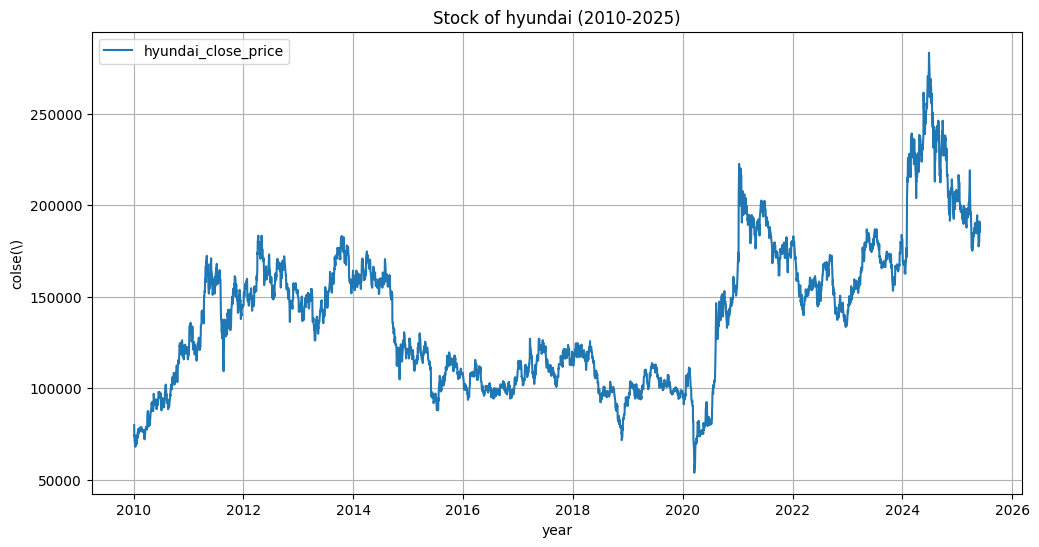

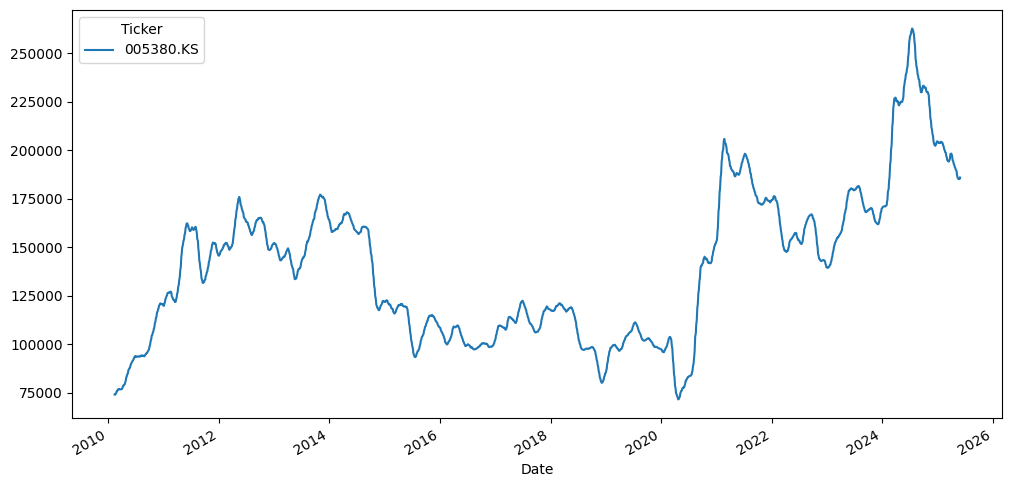

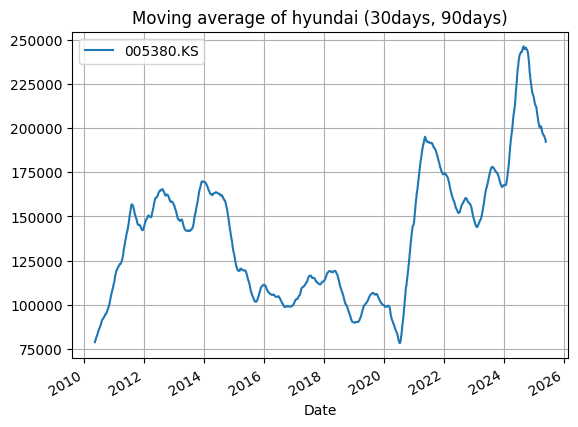

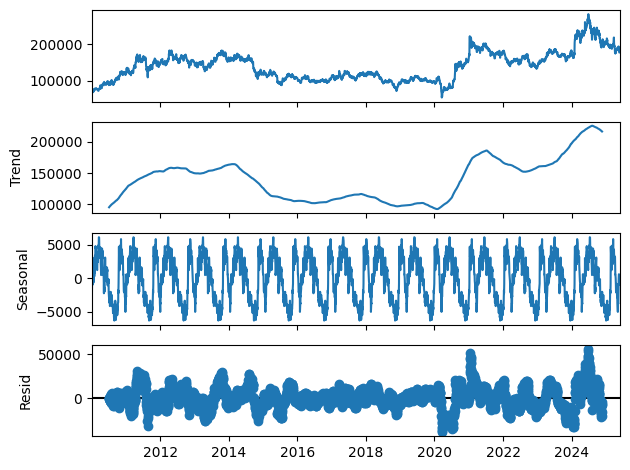

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

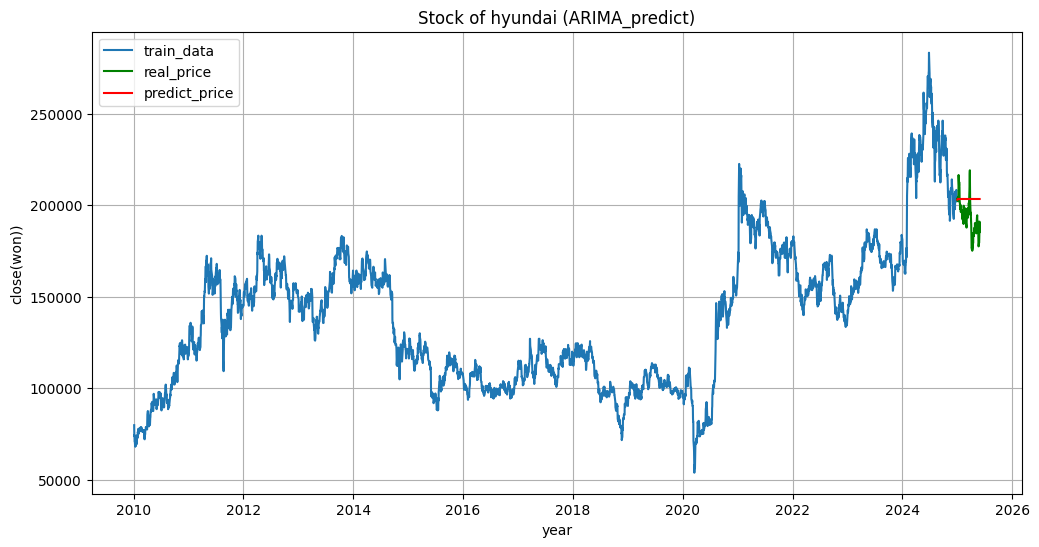

ARIMA_model RMSE: 13663.81


In [ ]:
# 1. 데이터 수집
hyundai = yf.download('005380.KS', start='2010-01-01', end='2025-06-01')
print(hyundai.head())

# 종가(close) 데이터 사용 및 결측치 제거
hyundai_close = hyundai['Close'].dropna()

# 데이터 시각화
plt.figure(figsize=(12, 6))
plt.plot(hyundai_close, label='hyundai_close_price')
plt.title('Stock of hyundai (2010-2025)')
plt.xlabel('year')
plt.ylabel('colse(\)')
plt.legend()
plt.grid(True)
plt.show()

# 이동평균 시각화 (30일, 90일)
hyundai_close.rolling(window=30).mean().plot(label='30days_moving average', figsize=(12,6))
hyundai_close.rolling(window=90).mean().plot(label='90days_moving average')
plt.title('Moving average of hyundai (30days, 90days)')
plt.legend()
plt.grid(True)
plt.show()

# 시계열 분해
decomposition = seasonal_decompose(hyundai_close, model='additive', period=252)  # 252 영업일 기준
decomposition.plot()
plt.show()

# ARIMA 모델로 예측
# 데이터 분리
train = hyundai_close[:'2024-12-31']
test = hyundai_close['2025-01-01':]

# ARIMA 모델 구축 및 예측 (모델 차수는 예시임)
model = ARIMA(train, order=(5,1,0))  # (p,d,q)는 조정 필요
model_fit = model.fit()

# 예측
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

# 예측 결과 시각화
plt.figure(figsize=(12,6))
plt.plot(train, label='train_data')
plt.plot(test, label='real_price', color='green')
plt.plot(forecast, label='predict_price', color='red')
plt.title('Stock of hyundai (ARIMA_predict)')
plt.xlabel('year')
plt.ylabel('close(won))')
plt.legend()
plt.grid(True)
plt.show()

# 모델 평가
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'ARIMA_model RMSE: {rmse:.2f}')

[*********************100%***********************]  1 of 1 completed
<ipython-input-19-860065367196>:13: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  hyundai_close.index = pd.DatetimeIndex(hyundai_close.index).to_period('B')
<ipython-input-19-860065367196>:16: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  train = hyundai_close[:'2024-12-31']
<ipython-input-19-860065367196>:17: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  test = hyundai_close['2025-01-01':'2025-02-01']
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:213: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  index = pd.period_range(
/usr/local/

<Figure size 1200x600 with 0 Axes>

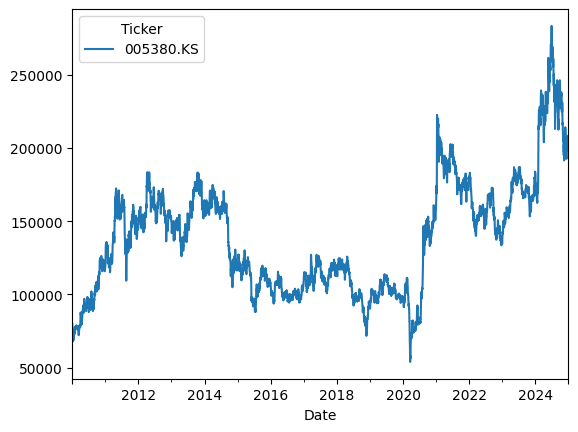

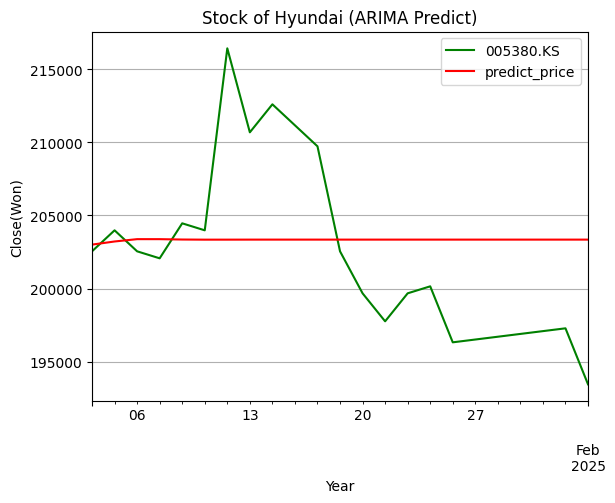

ARIMA_model RMSE: 5941.59


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# 데이터 수집
hyundai = yf.download('005380.KS', start='2010-01-01', end='2025-06-01')

# 데이터 전처리 (종가 사용, 결측치 제거)
hyundai_close = hyundai['Close'].dropna()

# 날짜 인덱스를 명확히 설정 (영업일)
hyundai_close.index = pd.DatetimeIndex(hyundai_close.index).to_period('B')

# 데이터 분리
train = hyundai_close[:'2024-12-31']
test = hyundai_close['2025-01-01':'2025-02-01']

# ARIMA 모델 구축 및 예측
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

# 예측값 생성
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

# 예측 결과 시각화
plt.figure(figsize=(12, 6))
train.plot(label='train_data')
test.plot(label='real_price', color='green')
forecast.plot(label='predict_price', color='red')

plt.title('Stock of Hyundai (ARIMA Predict)')
plt.xlabel('Year')
plt.ylabel('Close(Won)')
plt.legend()
plt.grid(True)

plt.show()

# 모델 평가 (RMSE)
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'ARIMA_model RMSE: {rmse:.2f}')


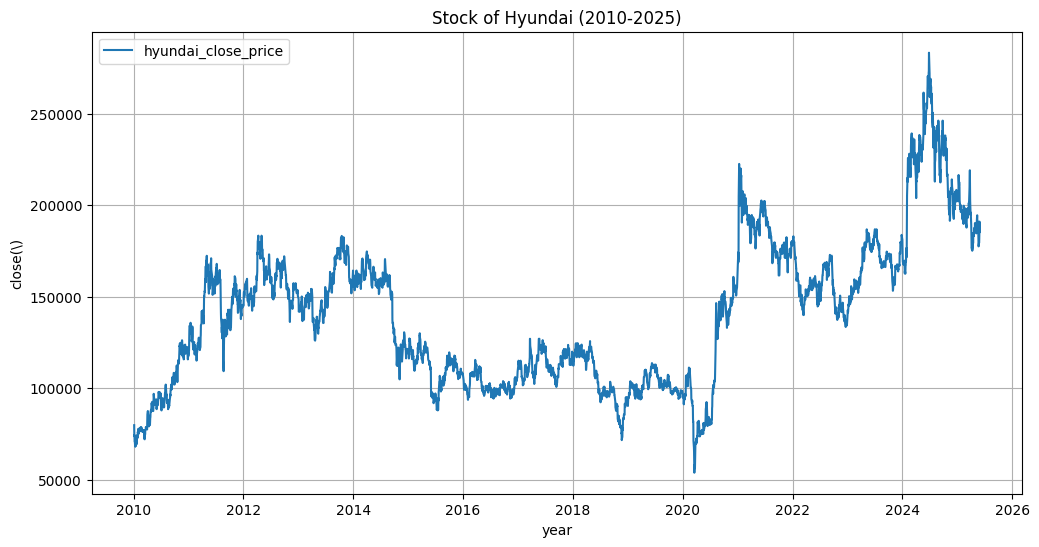

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(hyundai_close, label='hyundai_close_price')
plt.title('Stock of Hyundai (2010-2025)')
plt.xlabel('year')
plt.ylabel('close(\)')
plt.legend()
plt.grid(True)
plt.savefig('hyundai_stock_timeseries.png', dpi=300, bbox_inches='tight')  # 저장 코드 추가
plt.show()


<Figure size 1200x600 with 0 Axes>

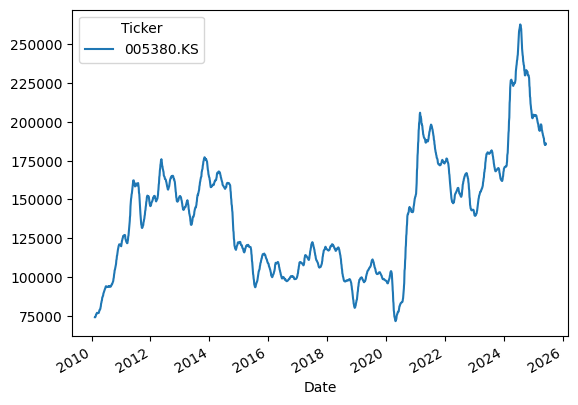

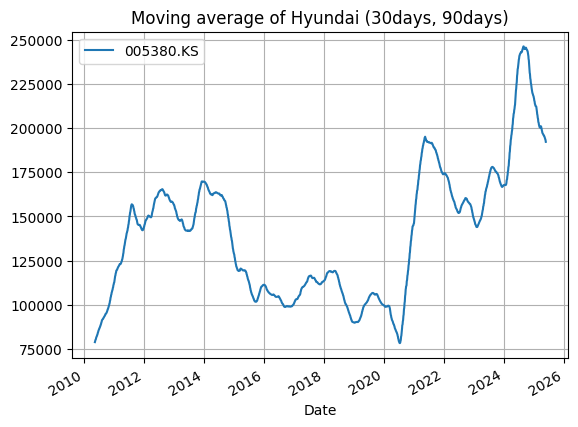

In [ ]:
plt.figure(figsize=(12,6))
hyundai_close.rolling(window=30).mean().plot(label='30days_moving average')
hyundai_close.rolling(window=90).mean().plot(label='90days_moving average')
plt.title('Moving average of Hyundai (30days, 90days)')
plt.legend()
plt.grid(True)
plt.savefig('hyundai_moving_average.png', dpi=300, bbox_inches='tight')  # 저장 코드 추가
plt.show()


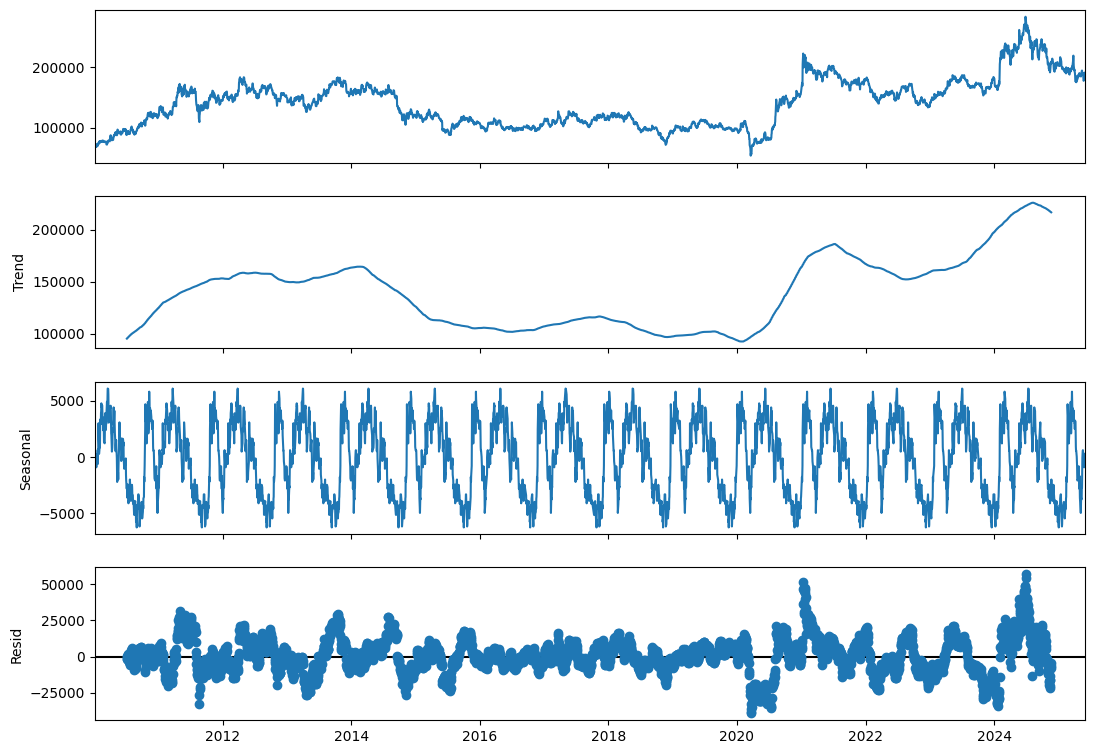

In [ ]:
decomposition = seasonal_decompose(hyundai_close, model='additive', period=252)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.savefig('hyundai_decomposition.png', dpi=300, bbox_inches='tight')  # 저장 코드 추가
plt.show()


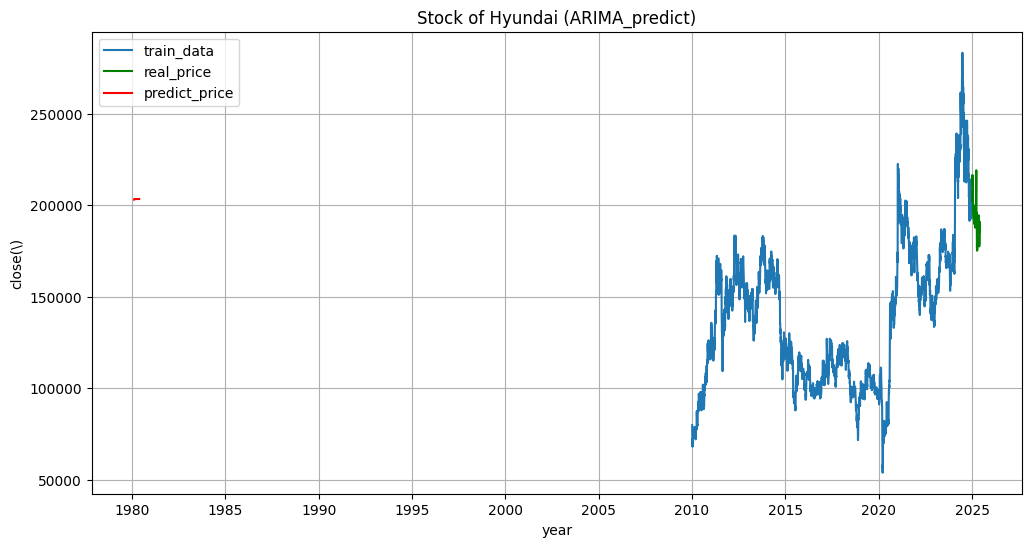

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train, label='train_data')
plt.plot(test, label='real_price', color='green')
plt.plot(forecast, label='predict_price', color='red')
plt.title('Stock of Hyundai (ARIMA_predict)')
plt.xlabel('year')
plt.ylabel('close(\)')
plt.legend()
plt.grid(True)
plt.savefig('hyundai_arima_prediction.png', dpi=300, bbox_inches='tight')  # 저장 코드 추가
plt.show()


In [ ]:
# Colab 환경인 경우 파일 저장 후 바로 다운로드 가능
from google.colab import files

plt.savefig('hyundai_stock_timeseries.png', dpi=300, bbox_inches='tight')
files.download('hyundai_stock_timeseries.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>